# 🔬 Hybrid Quantum-Classical-Quantum CNN (QCQ-CNN)
## Phân loại ảnh mẫu nhỏ trên tập MNIST (chữ số 3 và 5)

---
**Tóm tắt kiến trúc:**
```
Ảnh MNIST (28×28)
      ↓
[GIAI ĐOẠN 1] Quanvolutional Layer (PennyLane)
      → Trích xuất đặc trưng lượng tử → Feature map 14×14×4
      ↓
[GIAI ĐOẠN 2] Classical CNN (PyTorch)
      → Conv2d + MaxPool2d → Vector 2D
      ↓
[GIAI ĐOẠN 3] Quantum Classifier - QNN (Qiskit)
      → ZZFeatureMap + RealAmplitudes → Dự đoán nhị phân
```

---
## 📦 BƯỚC 1: Cài đặt và Import thư viện

### Giải thích:

Dự án này sử dụng **3 framework lượng tử/học sâu chính**, mỗi cái đóng một vai trò riêng biệt:

#### 🔵 PennyLane — Tầng Quanvolutional
PennyLane là thư viện lập trình lượng tử khả vi phân (differentiable quantum programming). Trong dự án này, nó được dùng để:
- Tạo **mạch lượng tử ngẫu nhiên** (Random Quantum Circuit) đóng vai trò như bộ lọc convolutional lượng tử.
- **Mã hóa góc (Angle Encoding)**: Biến giá trị pixel $x \in [0,1]$ thành góc quay $\theta = \pi \cdot x$ rồi áp vào cổng $R_Y(\theta)|0\rangle$.
  - Khi $x=0$: qubit ở trạng thái $|0\rangle$ (cực Bắc Bloch sphere)
  - Khi $x=1$: qubit ở trạng thái $|1\rangle$ (cực Nam Bloch sphere)
  - Giá trị xám giữa sẽ nằm trên mặt cầu Bloch, tận dụng không gian Hilbert để biểu diễn đặc trưng phi tuyến.
- Đo kỳ vọng $\langle Z_j \rangle = \langle \psi | Z_j | \psi \rangle \in [-1, 1]$ trên mỗi qubit làm đầu ra.

#### 🟠 PyTorch + Qiskit — Mạng CNN cổ điển + Phân loại lượng tử
- **PyTorch**: Xây dựng CNN cổ điển xử lý đặc trưng lượng tử (14×14×4) → vector 2D.
- **Qiskit + qiskit-machine-learning**: Tạo `EstimatorQNN` (mạng nơ-ron lượng tử) với `ZZFeatureMap` và `RealAmplitudes`, tích hợp liền mạch với PyTorch qua `TorchConnector`.
  - `ZZFeatureMap`: Mã hóa vector 2D vào trạng thái lượng tử dùng tương tác ZZ (feature entanglement).
  - `RealAmplitudes`: Ansatz với các cổng $R_Y$ có thể học và CNOT, tạo entanglement.

#### 🟢 TensorFlow/Keras — Các mô hình cơ sở (Baseline)
Dùng để xây dựng 4 mô hình so sánh: Classical MLP, Quanvo+MLP, Classical CNN, QCCNN.

In [ ]:
# Kết nối Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Tạo thư mục làm việc trên Drive
import os
work_dir = '/content/drive/MyDrive/QCQ_CNN_mnist_Project'
os.makedirs(work_dir, exist_ok=True)
os.chdir(work_dir)

Mounted at /content/drive


In [ ]:
# --- Cài đặt các thư viện cần thiết ---
# pennylane-lightning: C++ backend cho PennyLane, nhanh hơn ~5-10x so với default.qubit
# tqdm: Hiển thị progress bar khi trích xuất đặc trưng lượng tử
%pip install pennylane pennylane-lightning -q
%pip install qiskit>=1.0 qiskit-machine-learning>=0.7 -q
%pip install tqdm -q

# --- Xác nhận backend lightning khả dụng ---
import pennylane as qml
try:
    _dev_test = qml.device("lightning.qubit", wires=2)
    print("✅ pennylane-lightning: Cài đặt thành công — sẽ dùng C++ backend")
    del _dev_test
except Exception as e:
    print(f"⚠️  pennylane-lightning không khả dụng: {e}")
    print("   Sẽ tự động fallback về default.qubit (chậm hơn)")

✅ pennylane-lightning: Cài đặt thành công — sẽ dùng C++ backend


In [ ]:
# ============================================================
# BƯỚC 1: CÀI ĐẶT VÀ IMPORT THƯ VIỆN
# ============================================================

import os

# Tắt log C++ rườm rà của TensorFlow
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# ============================================================
# Ép TensorFlow/Keras chạy hoàn toàn trên CPU
# Lý do: TF và PyTorch KHÔNG chia sẻ CUDA context tốt trên Colab
# → TF chiếm GPU trước sẽ gây lỗi cho PyTorch và ngược lại
# → Keras chỉ dùng cho 4 baseline nhỏ (100 mẫu), CPU là đủ nhanh
# → PyTorch độc quyền GPU cho CNN + QCQ-CNN training
# ============================================================
os.environ['CUDA_VISIBLE_DEVICES'] = ''   # Ẩn GPU khỏi TensorFlow hoàn toàn

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.layers import Resizing

# Xác nhận TF đang dùng CPU
print(f"🔢 TensorFlow devices: {[d.name for d in tf.config.list_logical_devices()]}")

# ============================================================
# SAU KHI import TF xong, mới bật lại GPU cho PyTorch
# PyTorch dùng CUDA trực tiếp qua driver, không bị ảnh hưởng
# bởi CUDA_VISIBLE_DEVICES đã được đọc bởi TF ở trên
# ============================================================
os.environ['CUDA_VISIBLE_DEVICES'] = '0'   # Bật lại GPU cho PyTorch

# --- PennyLane ---
import pennylane as qml
from pennylane import numpy as np
from pennylane.templates import RandomLayers

# --- PyTorch ---
import torch
import torch.nn.functional as F
import torch.optim as optim
from torch.nn import Module, Conv2d, Linear, Dropout2d
from torch.utils.data import DataLoader, TensorDataset

# --- Qiskit ---
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit import QuantumCircuit
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector

# --- Thư viện phụ trợ ---
import numpy as std_np
import matplotlib.pyplot as plt
import math, time, random
from tqdm.auto import tqdm
from sklearn.metrics import confusion_matrix
import seaborn as sns

# --- Kiểm tra thiết bị ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n✅ Thư viện đã import thành công!")
print(f"📱 Thiết bị PyTorch : {device}")
if torch.cuda.is_available():
    print(f"   GPU  : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"⚛️  PennyLane        : {qml.__version__}")
print(f"🔬 PyTorch          : {torch.__version__}")
print(f"🔢 TensorFlow       : {tf.__version__}  (CPU only — GPU dành cho PyTorch)")

🔢 TensorFlow devices: ['/device:CPU:0']

✅ Thư viện đã import thành công!
📱 Thiết bị PyTorch : cuda
   GPU  : Tesla T4
   VRAM : 15.6 GB
⚛️  PennyLane        : 0.44.0
🔬 PyTorch          : 2.10.0+cu128
🔢 TensorFlow       : 2.19.0  (CPU only — GPU dành cho PyTorch)


---
## 📊 BƯỚC 2: Tải và Tiền xử lý Dữ liệu

### Giải thích:

#### 🎯 Tại sao chỉ dùng chữ số 3 và 5?
Bài báo nghiên cứu tập trung vào **phân loại nhị phân với mẫu nhỏ** — đây là điểm mạnh lý thuyết của QML. Chữ số 3 và 5 được chọn vì chúng **khó phân biệt nhất** trong MNIST (nhiều nét tương đồng về hình dạng).

#### ⚖️ Cân bằng dữ liệu (Balancing)
Để đánh giá công bằng, ta chọn **đúng $n$ mẫu mỗi lớp**:
- Train: 50 mẫu/lớp × 2 lớp = **100 mẫu**
- Test: 15 mẫu/lớp × 2 lớp = **30 mẫu**

Đây là setting "small-sample" — điều mà mô hình lượng tử được kỳ vọng hoạt động tốt.

#### 🔢 Ánh xạ nhãn
Nhãn gốc $\{3, 5\}$ được ánh xạ về $\{0, 1\}$:
$$y = \mathbb{1}[\text{nhãn gốc} = 5]$$
Tức là: chữ số 3 → nhãn 0, chữ số 5 → nhãn 1.

#### 📐 Chuẩn hóa (Normalization)
Pixel gốc $\in [0, 255]$ được chia cho 255 để về $[0, 1]$:
$$x_{\text{norm}} = \frac{x}{255}$$
Điều này **bắt buộc** vì Angle Encoding dùng $\theta = \pi \cdot x$, nếu $x > 1$ thì góc quay sẽ vượt quá $\pi$ gây mất ý nghĩa vật lý.

📊 THÔNG TIN DỮ LIỆU SAU TIỀN XỬ LÝ
Train images : (100, 28, 28, 1) | dtype: float64
Train labels : (100,) | Giá trị: [0 1]
Test  images : (30, 28, 28, 1)  | dtype: float64
Test  labels : (30,)  | Giá trị: [0 1]

Phân bố nhãn Train - Lớp 0: 50, Lớp 1: 50
Phân bố nhãn Test  - Lớp 0: 15,  Lớp 1: 15


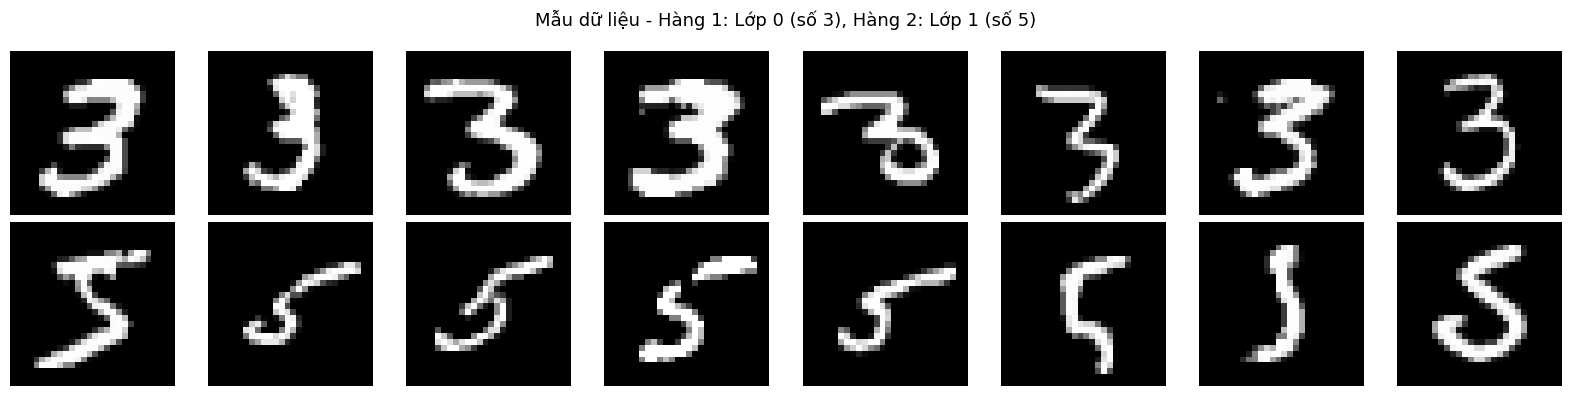

In [ ]:
# ============================================================
# BƯỚC 2: TẢI VÀ TIỀN XỬ LÝ DỮ LIỆU MNIST
# ============================================================

# --- Cấu hình ---
TARGET_LABELS = [3, 5]    # Hai chữ số cần phân loại
N_TRAIN_PER_CLASS = 50   # Số mẫu mỗi lớp cho train
N_TEST_PER_CLASS  = 15   # Số mẫu mỗi lớp cho test
N_EPOCHS = 100           # Số epoch huấn luyện

# --- 2.1: Tải toàn bộ MNIST ---
(all_train_images, all_train_labels), (all_test_images, all_test_labels) = \
    keras.datasets.mnist.load_data()

# --- 2.2: Lọc chỉ lấy chữ số 3 và 5 ---
train_mask = std_np.isin(all_train_labels, TARGET_LABELS)
test_mask  = std_np.isin(all_test_labels,  TARGET_LABELS)

train_images = all_train_images[train_mask]   # Chỉ giữ ảnh có nhãn 3 hoặc 5
train_labels = all_train_labels[train_mask]
test_images  = all_test_images[test_mask]
test_labels  = all_test_labels[test_mask]

# --- 2.3: Ánh xạ nhãn {3,5} → {0,1} ---
# Chữ số 3 → 0 (lớp âm), chữ số 5 → 1 (lớp dương)
train_labels = (train_labels == TARGET_LABELS[1]).astype(std_np.int32)
test_labels  = (test_labels  == TARGET_LABELS[1]).astype(std_np.int32)

# --- 2.4: Hàm chọn tập con cân bằng ---
def select_balanced_subset(tr_imgs, tr_lbls, te_imgs, te_lbls,
                           per_class_train, per_class_test):
    """
    Chọn đúng per_class_train mẫu mỗi lớp cho train
    và per_class_test mẫu mỗi lớp cho test.
    Đảm bảo dữ liệu cân bằng giữa 2 lớp.
    """
    sel_tr_imgs, sel_tr_lbls = [], []
    sel_te_imgs, sel_te_lbls = [], []

    for label_val in [0, 1]:  # Lần lượt xử lý lớp 0 và lớp 1
        # Tìm chỉ số của các mẫu thuộc lớp label_val
        tr_idx = std_np.where(tr_lbls == label_val)[0][:per_class_train]
        te_idx = std_np.where(te_lbls == label_val)[0][:per_class_test]

        sel_tr_imgs.append(tr_imgs[tr_idx])
        sel_tr_lbls.append(tr_lbls[tr_idx])
        sel_te_imgs.append(te_imgs[te_idx])
        sel_te_lbls.append(te_lbls[te_idx])

    # Ghép lại thành một mảng duy nhất
    return (
        std_np.concatenate(sel_tr_imgs, axis=0),
        std_np.concatenate(sel_tr_lbls, axis=0),
        std_np.concatenate(sel_te_imgs, axis=0),
        std_np.concatenate(sel_te_lbls, axis=0)
    )

# --- 2.5: Chọn tập con cân bằng ---
train_images, train_labels, test_images, test_labels = select_balanced_subset(
    train_images, train_labels,
    test_images,  test_labels,
    per_class_train=N_TRAIN_PER_CLASS,
    per_class_test=N_TEST_PER_CLASS
)

# --- 2.6: Chuẩn hóa về [0,1] và thêm chiều kênh ---
train_images = train_images / 255.0          # Đưa pixel về [0,1]
test_images  = test_images  / 255.0
train_images = train_images[..., std_np.newaxis]  # (N, 28, 28) → (N, 28, 28, 1)
test_images  = test_images[..., std_np.newaxis]

# --- Kiểm tra kết quả ---
print("=" * 50)
print("📊 THÔNG TIN DỮ LIỆU SAU TIỀN XỬ LÝ")
print("=" * 50)
print(f"Train images : {train_images.shape} | dtype: {train_images.dtype}")
print(f"Train labels : {train_labels.shape} | Giá trị: {std_np.unique(train_labels)}")
print(f"Test  images : {test_images.shape}  | dtype: {test_images.dtype}")
print(f"Test  labels : {test_labels.shape}  | Giá trị: {std_np.unique(test_labels)}")
print(f"\nPhân bố nhãn Train - Lớp 0: {(train_labels==0).sum()}, Lớp 1: {(train_labels==1).sum()}")
print(f"Phân bố nhãn Test  - Lớp 0: {(test_labels==0).sum()},  Lớp 1: {(test_labels==1).sum()}")

# --- Trực quan hóa một số mẫu ---
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle('Mẫu dữ liệu - Hàng 1: Lớp 0 (số 3), Hàng 2: Lớp 1 (số 5)', fontsize=13)
cls0 = std_np.where(train_labels == 0)[0]
cls1 = std_np.where(train_labels == 1)[0]
for i in range(8):
    axes[0, i].imshow(train_images[cls0[i], :, :, 0], cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(train_images[cls1[i], :, :, 0], cmap='gray')
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

---
## ⚛️ BƯỚC 3: Xây dựng Quanvolutional Layer và Trích xuất Đặc trưng Lượng tử

### Giải thích:

#### 💡 Ý tưởng Quanvolutional Layer là gì?
Trong CNN cổ điển, một bộ lọc (filter) trượt qua ảnh và tính **tổ hợp tuyến tính** của các pixel. Quanvolutional layer thay thế phép tính đó bằng **một mạch lượng tử ngẫu nhiên**, cho phép trích xuất đặc trưng **phi tuyến phức tạp** từ không gian Hilbert — điều mà bộ lọc tuyến tính không làm được.

#### 🔄 Quy trình xử lý mỗi patch 2×2:

**Bước 1 — Lấy patch:** Lấy vùng 2×2 pixel từ ảnh → 4 giá trị $[x_0, x_1, x_2, x_3] \in [0,1]$

**Bước 2 — Angle Encoding (Mã hóa góc):**
$$|\psi_{\text{enc}}\rangle = \bigotimes_{j=0}^{3} R_Y(\pi x_j)|0\rangle_j$$
Mỗi qubit $j$ được xoay một góc $\theta_j = \pi x_j$ quanh trục Y trên Bloch sphere.

**Bước 3 — Random Quantum Circuit:**
Áp dụng `RandomLayers` với tham số $\mathbf{\theta}_{\text{rand}}$ ngẫu nhiên (cố định sau khi khởi tạo).

**Bước 4 — Đo lường:**
$$o_j = \langle \psi | Z_j | \psi \rangle \in [-1, 1], \quad j = 0,1,2,3$$
4 giá trị kỳ vọng Pauli-Z → 4 "kênh" đặc trưng.

#### 📐 Kích thước đầu vào/ra:
- **Đầu vào:** Ảnh (28×28×1)
- **Patch size:** 2×2, **Stride:** 2
- **Đầu ra mỗi ảnh:** $\lfloor (28-2)/2 \rfloor + 1 = 14$ → Feature map **(14×14×4)**

#### ⚠️ Lưu ý về thời gian:
Mỗi ảnh cần chạy $14 \times 14 = 196$ mạch lượng tử. Với 130 ảnh, tổng cộng ~25,480 lần chạy mạch. **Đây là bước tốn thời gian nhất!** Do đó, ta lưu kết quả vào file `.npy` để tái sử dụng.

In [ ]:
# ============================================================
# BƯỚC 3A: ĐỊNH NGHĨA QUANVOLUTIONAL LAYER
# ============================================================

class Quanvolutional_Layer():
    """
    Tầng Quanvolutional: Thay bộ lọc CNN cổ điển bằng mạch lượng tử ngẫu nhiên.

    Tham số:
        size_filter  : Kích thước bộ lọc vuông (ví dụ: 2 → bộ lọc 2×2)
        layers_filter: Số lớp RandomLayers (= số 'kênh' đầu ra)
        stride_filter: Bước trượt của bộ lọc
        padding      : Đệm (chưa cài đặt, để 0)
    """

    def __init__(self, size_filter, layers_filter, stride_filter, padding):
        self.size_filter   = size_filter
        self.layers_filter = layers_filter
        self.stride_filter = stride_filter
        self.padding       = padding

        # Số qubit = size_filter² (bộ lọc 2×2 → 4 qubit)
        n_qubits = self.size_filter * self.size_filter

        # --- Chọn backend simulator nhanh nhất có thể ---
        # lightning.qubit: Được viết bằng C++/C với BLAS, nhanh hơn default.qubit ~5-10x
        # default.qubit: Thuần Python, dùng làm fallback nếu lightning chưa cài
        try:
            self.dev = qml.device("lightning.qubit", wires=n_qubits)
            self._backend_name = "lightning.qubit (C++ — nhanh)"
        except Exception:
            self.dev = qml.device("default.qubit", wires=n_qubits)
            self._backend_name = "default.qubit (Python — fallback)"

        # Tham số ngẫu nhiên cho RandomLayers — cố định để đảm bảo tái lập
        # Shape: (layers_filter, n_qubits) — mỗi layer có n_qubits tham số
        self.rand_params = np.random.uniform(
            high=2 * np.pi,
            size=(self.layers_filter, n_qubits)
        )

        print(f"✅ Quanvolutional_Layer khởi tạo thành công!")
        print(f"   Backend   : {self._backend_name}")
        print(f"   Bộ lọc   : {size_filter}×{size_filter}, Stride: {stride_filter}")
        print(f"   Số qubit  : {n_qubits}, Số kênh đầu ra: {layers_filter}")

    def creator(self, phi):
        """
        Tạo và chạy mạch lượng tử cho một patch.

        phi: vector pixel của patch, shape=(n_qubits,)
        Trả về: danh sách [layers_filter x n_qubits] kỳ vọng PauliZ
        """
        n_qubits = self.size_filter * self.size_filter

        # interface='numpy': Tắt autograd của PennyLane vì rand_params không cần gradient
        # → nhanh hơn so với interface='auto' mặc định khi chỉ cần inference
        @qml.qnode(self.dev, interface='numpy')
        def circuit(phi):
            op_list = []

            # === ANGLE ENCODING ===
            # Mỗi pixel phi[j] ∈ [0,1] được mã hóa bằng góc θ = π * phi[j]
            # RY(θ)|0⟩ = cos(θ/2)|0⟩ + sin(θ/2)|1⟩
            for j in range(n_qubits):
                qml.RY(np.pi * phi[j], wires=j)

            # === RANDOM QUANTUM CIRCUIT ===
            # Áp dụng RandomLayers với mỗi hàng của rand_params
            for k in self.rand_params:
                tmp = np.expand_dims(k, axis=0)  # Shape: (1, n_qubits)
                RandomLayers(tmp, wires=list(range(n_qubits)))

                # === ĐO LƯỜNG: Kỳ vọng Pauli-Z trên mỗi qubit ===
                # ⟨Z_j⟩ = P(|0⟩) - P(|1⟩) ∈ [-1, 1]
                for j in range(n_qubits):
                    op_list.append(qml.expval(qml.PauliZ(j)))

            return op_list

        op_list = circuit(phi)
        op_list = np.array(op_list)
        # Reshape về (layers_filter, n_qubits)
        return list(np.reshape(op_list, (self.layers_filter, n_qubits)))

    def call(self, image_batch):
        """
        Áp dụng Quanvolutional layer lên toàn bộ batch ảnh.

        image_batch: shape (N, H, W, 1)
        Trả về: list N phần tử, mỗi phần tử shape (H_out, W_out, C_out)
        """
        H, W = image_batch[0].shape[0], image_batch[0].shape[1]

        # Tính kích thước đầu ra theo công thức CNN:
        # H_out = floor((H + 2*padding - size_filter) / stride) + 1
        H_out = math.floor((H + 2*self.padding - self.size_filter) / self.stride_filter) + 1
        C_out = self.layers_filter * (self.size_filter * self.size_filter)

        print(f"   Kích thước input mỗi ảnh : {H}×{W}")
        print(f"   Kích thước output mỗi ảnh: {H_out}×{H_out}×{C_out}")

        if H_out < 1:
            raise ValueError("Kích thước bộ lọc quá lớn so với ảnh!")

        collection = []

        # Dùng tqdm thay cho print thủ công "Đang xử lý ảnh [x/N]"
        # tqdm tự hiển thị thanh tiến trình + tốc độ + ETA
        for idx, img in enumerate(tqdm(image_batch, desc="⚛️  Quanvolution")):
            # Khởi tạo tensor đầu ra cho ảnh hiện tại
            out = np.zeros((H_out, H_out, C_out))

            # Trượt bộ lọc với stride
            for j in range(0, H, self.stride_filter):
                for k in range(0, W, self.stride_filter):
                    # Bỏ qua patch vượt ra ngoài biên ảnh
                    if (j + self.size_filter > H) or (k + self.size_filter > W):
                        continue

                    # Lấy pixel trong patch 2×2
                    phi = []
                    for l in range(j, j + self.size_filter):
                        for m in range(k, k + self.size_filter):
                            phi.append(img[l][m][0])  # Kênh 0 (grayscale)

                    # Chạy mạch lượng tử và lấy kết quả đo
                    q_results = self.creator(phi)

                    # Ghi kết quả vào tensor đầu ra
                    ctr = 0
                    for x in q_results:
                        for y_val in x:
                            out[j//self.stride_filter, k//self.stride_filter, ctr] = y_val
                            ctr += 1

            collection.append(out)

        print(f"✅ Xử lý xong {len(image_batch)} ảnh!")
        return collection

In [ ]:
# ============================================================
# BƯỚC 3B: TRÍCH XUẤT VÀ LƯU ĐẶC TRƯNG LƯỢNG TỬ
# ============================================================

# --- Cấu hình đường dẫn lưu file ---
# Đặt USE_GDRIVE = True nếu muốn lưu vào Google Drive
# (đặc trưng sẽ không bị mất khi Colab reset runtime)
USE_GDRIVE = False   # ← ĐỔI THÀNH True nếu cần lưu lâu dài

if USE_GDRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_DIR = '/content/drive/MyDrive/QCQ_CNN_Features'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"📁 Lưu vào Google Drive: {SAVE_DIR}")
else:
    SAVE_DIR = "."   # Thư mục hiện tại (mặc định Colab /content/)

TRAIN_FEATURES_PATH = os.path.join(SAVE_DIR, "MNIST_op_train.npy")
TEST_FEATURES_PATH  = os.path.join(SAVE_DIR, "MNIST_op_test.npy")

# --- Kiểm tra file đã tồn tại (tránh chạy lại tốn thời gian) ---
if os.path.exists(TRAIN_FEATURES_PATH) and os.path.exists(TEST_FEATURES_PATH):
    print("📂 Tìm thấy file đặc trưng đã lưu. Đang tải...")
    op_train = std_np.load(TRAIN_FEATURES_PATH).astype(std_np.float32)
    op_test  = std_np.load(TEST_FEATURES_PATH).astype(std_np.float32)
    print(f"✅ Đã tải xong!")
else:
    print("🚀 Bắt đầu trích xuất đặc trưng lượng tử...")
    print("   Cấu hình: size_filter=2, layers_filter=1, stride=2, padding=0")
    print("   Ước tính: ~196 mạch/ảnh × 130 ảnh = 25,480 lần chạy mạch")
    print("   (Với lightning.qubit nhanh hơn ~5-10x so với default.qubit)\n")

    # Khởi tạo layer: bộ lọc 2×2, 1 layer, stride 2, không padding
    # → Đầu ra: 14×14×4 (1 layer × 4 qubit = 4 kênh)
    Quan2D = Quanvolutional_Layer(
        size_filter=2,
        layers_filter=1,
        stride_filter=2,
        padding=0
    )

    print("\n[TRAIN SET]")
    t_start = time.time()
    op_train_list = Quan2D.call(train_images)
    op_train = std_np.asarray(op_train_list, dtype=std_np.float32)
    t_train = time.time() - t_start

    print(f"\n[TEST SET]")
    op_test_list = Quan2D.call(test_images)
    op_test = std_np.asarray(op_test_list, dtype=std_np.float32)

    # Lưu kết quả
    std_np.save(TRAIN_FEATURES_PATH, op_train)
    std_np.save(TEST_FEATURES_PATH,  op_test)
    print(f"\n💾 Đã lưu đặc trưng:")
    print(f"   Train → {TRAIN_FEATURES_PATH}")
    print(f"   Test  → {TEST_FEATURES_PATH}")
    print(f"⏱️  Thời gian xử lý train set: {t_train:.1f} giây")

# --- Kiểm tra kích thước đặc trưng ---
print("\n" + "=" * 50)
print("📐 KÍCH THƯỚC ĐẶC TRƯNG LƯỢNG TỬ")
print("=" * 50)
print(f"op_train : {op_train.shape}  (N_train × H_out × W_out × C)")
print(f"op_test  : {op_test.shape}   (N_test  × H_out × W_out × C)")
print(f"Giá trị min/max: [{op_train.min():.3f}, {op_train.max():.3f}]")

🚀 Bắt đầu trích xuất đặc trưng lượng tử...
   Cấu hình: size_filter=2, layers_filter=1, stride=2, padding=0
   Ước tính: ~196 mạch/ảnh × 130 ảnh = 25,480 lần chạy mạch
   (Với lightning.qubit nhanh hơn ~5-10x so với default.qubit)

✅ Quanvolutional_Layer khởi tạo thành công!
   Backend   : lightning.qubit (C++ — nhanh)
   Bộ lọc   : 2×2, Stride: 2
   Số qubit  : 4, Số kênh đầu ra: 1

[TRAIN SET]
   Kích thước input mỗi ảnh : 28×28
   Kích thước output mỗi ảnh: 14×14×4


⚛️  Quanvolution:   0%|          | 0/100 [00:00<?, ?it/s]

✅ Xử lý xong 100 ảnh!

[TEST SET]
   Kích thước input mỗi ảnh : 28×28
   Kích thước output mỗi ảnh: 14×14×4


⚛️  Quanvolution:   0%|          | 0/30 [00:00<?, ?it/s]

✅ Xử lý xong 30 ảnh!

💾 Đã lưu đặc trưng:
   Train → ./MNIST_op_train.npy
   Test  → ./MNIST_op_test.npy
⏱️  Thời gian xử lý train set: 77.4 giây

📐 KÍCH THƯỚC ĐẶC TRƯNG LƯỢNG TỬ
op_train : (100, 14, 14, 4)  (N_train × H_out × W_out × C)
op_test  : (30, 14, 14, 4)   (N_test  × H_out × W_out × C)
Giá trị min/max: [-1.000, 1.000]


---
## 🏗️ BƯỚC 4: Định nghĩa Các Mô hình

### Giải thích:

Chúng ta sẽ định nghĩa **5 mô hình** — 4 baseline Keras và 1 mô hình đề xuất PyTorch+Qiskit:

#### 📌 Mô hình 1: Classical MLP (`MyModel`)
Nhận đặc trưng lượng tử (14×14×4) → Flatten → Dense layers → Softmax. Đây là baseline đơn giản nhất.

#### 📌 Mô hình 2: Quanvo + MLP
Giống MyModel nhưng nhận đầu vào ảnh gốc sau khi resize 14×14×1. Đánh giá xem đặc trưng lượng tử có giúp ích hay không.

#### 📌 Mô hình 3: Classical CNN
CNN thuần túy trên ảnh gốc (28×28×1). So sánh với kiến trúc không có tầng lượng tử.

#### 📌 Mô hình 4: QCCNN (Quantum + Classical CNN)
CNN Keras trên đặc trưng lượng tử (14×14×4). Giai đoạn phân loại vẫn là cổ điển.

#### 📌 Mô hình 5: **QCQ-CNN** (Mô hình đề xuất)
Kiến trúc 3 giai đoạn đầy đủ:
1. **Đặc trưng lượng tử** (14×14×4) từ PennyLane
2. **CNN PyTorch**: `Conv2d(4→8, 3×3)` → `ReLU` → `MaxPool(2)` → `Conv2d(8→16, 3×3)` → `ReLU` → `MaxPool(2)` → `Dropout` → `Flatten` → `Linear(→2)`
3. **QNN Qiskit**: Vector 2D → `ZZFeatureMap(2)` → `RealAmplitudes(2, reps=1)` → `EstimatorQNN` → `TorchConnector` → `Linear(1→2)` → Softmax

Công thức QNN:
$$\hat{y} = \text{Linear}\big(\langle \psi(\mathbf{x};\theta_{\text{QNN}}) | H | \psi(\mathbf{x};\theta_{\text{QNN}}) \rangle\big)$$
trong đó $\mathbf{x}$ là vector 2D đầu vào, $\theta_{\text{QNN}}$ là tham số có thể học của ansatz.

In [ ]:
# ============================================================
# BƯỚC 4A: CÁC MÔ HÌNH BASELINE (KERAS)
# ============================================================

# --- Model 1: MLP trên đặc trưng lượng tử (Quanvo + MLP) ---
def build_mlp_on_quantum_features():
    """
    MLP đơn giản nhận đặc trưng lượng tử (14×14×4) làm đầu vào.
    Đây là baseline Quanvo + MLP.
    """
    # Dùng keras.Input() thay cho input_shape= trong layer đầu tiên
    # → Keras 3.x không build graph ngay, tránh crash CUDA khi chưa có GPU context
    model = keras.Sequential([
        keras.Input(shape=(14, 14, 4)),       # ← Thay Flatten(input_shape=...)
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(2,  activation='softmax'),
    ], name="MLP_on_QuantumFeatures")
    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# --- Model 2: Classical MLP thuần túy (trên ảnh gốc) ---
def build_classical_mlp():
    """
    MLP thuần cổ điển trên ảnh 28×28×1.
    Baseline không dùng đặc trưng lượng tử.
    """
    model = keras.Sequential([
        keras.Input(shape=(28, 28, 1)),       # ← Thay Flatten(input_shape=...)
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(2,  activation='softmax'),
    ], name="Classical_MLP")
    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# --- Model 3: Classical CNN trên ảnh gốc ---
def build_classical_cnn():
    """
    CNN cổ điển 2 lớp trên ảnh 28×28×1.
    Baseline CNN không có tầng lượng tử.
    """
    model = keras.Sequential([
        keras.Input(shape=(28, 28, 1)),       # ← Thay Resizing(input_shape=...)
        Resizing(14, 14),                     # Resize về 14×14 để cùng scale với quantum features
        layers.Conv2D(4, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(8, (3, 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(2, activation='softmax'),
    ], name="Classical_CNN")
    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# --- Model 4: QCCNN — CNN Keras trên đặc trưng lượng tử ---
def build_qccnn():
    """
    CNN Keras xử lý đặc trưng lượng tử (14×14×4).
    = Quanvolutional + Classical CNN (không có QNN ở cuối).
    """
    model = keras.Sequential([
        keras.Input(shape=(14, 14, 4)),       # ← Thay Conv2D(input_shape=...)
        layers.Conv2D(4, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(8, (3, 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(2, activation='softmax'),
    ], name="QCCNN")
    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# --- Kiểm tra kiến trúc ---
print("=" * 50)
print("📋 KIẾN TRÚC CÁC MÔ HÌNH BASELINE (Keras):")
print("=" * 50)

for build_fn, name in [
    (build_classical_mlp,          "Classical MLP"),
    (build_mlp_on_quantum_features,"Quanvo + MLP"),
    (build_classical_cnn,          "Classical CNN"),
    (build_qccnn,                  "QCCNN"),
]:
    print(f"\n{'─'*50}")
    print(f"📌 {name}")
    print(f"{'─'*50}")
    build_fn().summary()

📋 KIẾN TRÚC CÁC MÔ HÌNH BASELINE (Keras):

──────────────────────────────────────────────────
📌 Classical MLP
──────────────────────────────────────────────────


Model: "Classical_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,386 (204.63 KB)

 Trainable params: 52,386 (204.63 KB)

...

Model: "QCCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 4)      │           148 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 4)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 8)        │           296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 510 (1.99 KB)

 Trainable params: 510 (1.99 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# BƯỚC 4B: MÔ HÌNH ĐỀ XUẤT QCQ-CNN (PYTORCH + QISKIT)
# ============================================================

def create_qnn():
    """
    Tạo Mạng Nơ-ron Lượng tử (QNN) dùng Qiskit.

    Cấu trúc mạch:
    [ZZFeatureMap(2)] → [RealAmplitudes(2, reps=1)]

    - ZZFeatureMap: Mã hóa vector 2D vào trạng thái lượng tử
      Dùng cổng H và cổng ZZ-interaction: e^{i(π-x₁)(π-x₂)Z⊗Z}

    - RealAmplitudes: Ansatz với RY và CNOT gates
      Tham số: 4 tham số (2 qubits × 2 layers = 2×reps+2 = 4)

    - EstimatorQNN: Tính kỳ vọng ⟨H⟩ = ⟨ψ|Z⊗I|ψ⟩ (mặc định)
      Đầu ra: scalar ∈ [-1, 1]

    ⚠️ Lưu ý phần cứng:
      EstimatorQNN của Qiskit KHÔNG hỗ trợ CUDA — luôn chạy trên CPU.
      QCQ_CNN.forward() sẽ tự xử lý việc chuyển tensor CPU↔GPU.
    """
    feature_map = ZZFeatureMap(2)            # 2 qubit, mã hóa 2 đặc trưng
    ansatz      = RealAmplitudes(2, reps=1)  # 2 qubit, 1 lớp lặp, 4 tham số

    # Ghép feature map + ansatz thành một mạch hoàn chỉnh
    qc = QuantumCircuit(2)
    qc.compose(feature_map, inplace=True)
    qc.compose(ansatz,      inplace=True)

    # Tạo EstimatorQNN — hỗ trợ tính gradient tự động qua parameter-shift rule
    qnn = EstimatorQNN(
        circuit=qc,
        input_params=feature_map.parameters,  # Tham số đầu vào (x₁, x₂)
        weight_params=ansatz.parameters,       # Tham số có thể học (θ₀..θ₃)
        input_gradients=True,                  # Bật tính gradient theo đầu vào
    )
    return qnn


class QCQ_CNN(Module):
    """
    Mô hình QCQ-CNN đề xuất: Kết hợp CNN cổ điển và QNN.

    Luồng dữ liệu:
    Input (N, 4, 14, 14)
        → conv1: (N, 8, 12, 12)    [Conv2d(4→8, 3×3) + ReLU]
        → MaxPool: (N, 8, 6, 6)
        → conv2: (N, 16, 4, 4)     [Conv2d(8→16, 3×3) + ReLU]
        → MaxPool: (N, 16, 2, 2)
        → Dropout2d
        → Flatten: (N, 64)
        → fc2: (N, 2)              [Linear(64→2), lazy init]
        → [CPU] QNN: (N, 1)        [TorchConnector — luôn CPU]
        → [GPU] fc3: (N, 2)        [Linear(1→2)]

    Ghi chú device:
        - conv1, conv2, dropout, fc2, fc3: Chạy trên device của input (GPU nếu có)
        - qnn (TorchConnector): Luôn chạy trên CPU (giới hạn của Qiskit)
        - forward() tự động chuyển tensor CPU↔GPU tại đúng điểm cần thiết
    """

    def __init__(self, qnn):
        super().__init__()
        # Lớp Conv2d thứ nhất: 4 kênh vào → 8 kênh ra, kernel 3×3
        self.conv1   = Conv2d(4, 8, 3)
        # Lớp Conv2d thứ hai: 8 kênh vào → 16 kênh ra, kernel 3×3
        self.conv2   = Conv2d(8, 16, 3)
        # Dropout ngẫu nhiên các kênh (chống overfitting)
        self.dropout = Dropout2d()
        # fc2 được khởi tạo động ở forward() vì phụ thuộc kích thước flatten
        self.fc2     = None
        # TorchConnector: Kết nối QNN Qiskit với PyTorch autograd
        # Không gọi .to(device) cho self.qnn — Qiskit không hỗ trợ CUDA
        self.qnn     = TorchConnector(qnn)
        # Lớp cuối: chuyển scalar QNN sang 2 logit lớp
        self.fc3     = Linear(1, 2)

    def forward(self, x):
        # x nằm trên GPU nếu được chuyển bằng .to(device) từ train loop

        # --- Phần CNN: Chạy trên GPU ---
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)

        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)

        x = self.dropout(x)

        # Flatten về vector 1D (giữ nguyên batch dimension)
        x = x.view(x.shape[0], -1)

        # Khởi tạo fc2 động dựa trên kích thước thực tế sau flatten
        if self.fc2 is None:
            self.fc2 = Linear(x.shape[1], 2).to(x.device)

        # FC2: Nén xuống 2 đặc trưng để đưa vào QNN (2 qubit cần 2 input)
        x = self.fc2(x)   # x vẫn trên GPU ở đây

        # --- Chuyển CPU cho QNN (Qiskit không hỗ trợ CUDA) ---
        # .cpu() tách tensor khỏi GPU và tạo bản sao trên RAM
        # Gradient vẫn được giữ nguyên qua phép chuyển này
        x_cpu = x.cpu()

        # QNN: Xử lý 2 đặc trưng qua mạch lượng tử trên CPU
        # Đầu ra: (batch, 1) — scalar kỳ vọng lượng tử ∈ [-1, 1]
        x_qnn = self.qnn(x_cpu)

        # --- Chuyển trở lại device gốc (GPU) để fc3 và loss tính trên GPU ---
        # Đảm bảo gradient flow thông suốt từ fc3 → QNN → fc2 → CNN
        x_qnn = x_qnn.to(x.device)

        # FC3: Chuyển scalar QNN → 2 logit lớp
        return self.fc3(x_qnn)


# --- Kiểm tra kiến trúc ---
print("=" * 55)
print("📋 KIẾN TRÚC QCQ-CNN (PyTorch + Qiskit):")
print("=" * 55)
_test_qnn   = create_qnn()
_test_model = QCQ_CNN(_test_qnn)

# Warm-up forward pass để khởi tạo fc2 (lazy layer)
_dummy_input = torch.zeros(1, 4, 14, 14)
_ = _test_model(_dummy_input)

print(_test_model)
total_params = sum(p.numel() for p in _test_model.parameters() if p.requires_grad)
print(f"\n📊 Tổng tham số có thể học: {total_params:,}")
print(f"   (CNN params + QNN params = {total_params - 4:,} + 4)")
del _test_qnn, _test_model, _dummy_input   # Giải phóng bộ nhớ

/tmp/ipykernel_28685/4285590140.py:25: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(2)            # 2 qubit, mã hóa 2 đặc trưng
/tmp/ipykernel_28685/4285590140.py:26: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz      = RealAmplitudes(2, reps=1)  # 2 qubit, 1 lớp lặp, 4 tham số


📋 KIẾN TRÚC QCQ-CNN (PyTorch + Qiskit):
QCQ_CNN(
  (conv1): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
  (dropout): Dropout2d(p=0.5, inplace=False)
  (qnn): TorchConnector()
  (fc3): Linear(in_features=1, out_features=2, bias=True)
  (fc2): Linear(in_features=64, out_features=2, bias=True)
)

📊 Tổng tham số có thể học: 1,602
   (CNN params + QNN params = 1,598 + 4)


---
## 🏋️ BƯỚC 5: Vòng lặp Huấn luyện

### Giải thích:

#### 🔵 Huấn luyện Baseline (Keras)
Keras dùng API `model.fit()` với:
- **Loss**: `sparse_categorical_crossentropy` — phù hợp khi nhãn là số nguyên (0, 1)
  $$L = -\sum_{i} y_i \log(\hat{p}_i)$$
- **Optimizer**: Adam với learning rate 0.001
- **Batch size**: 4 (nhỏ phù hợp với dataset nhỏ)

#### 🟠 Chuẩn bị DataLoader (PyTorch)
Đặc trưng lượng tử cần **chuyển sang định dạng PyTorch**:
- Numpy (N, 14, 14, 4) → Tensor (N, 4, 14, 14) [channels-first theo convention PyTorch]
- `TensorDataset` + `DataLoader` với batch_size=1

#### 🔴 Vòng lặp huấn luyện QCQ-CNN (PyTorch)
```
for epoch in range(100):
    for batch in train_loader:
        optimizer.zero_grad()     # Xóa gradient cũ
        output = model(data)      # Forward pass
        loss = CrossEntropy(output, label)  # Tính loss
        loss.backward()           # Backprop qua cả CNN + QNN!
        optimizer.step()          # Cập nhật tham số
```
Điểm đặc biệt: `loss.backward()` tự động tính gradient **xuyên qua** cả lớp CNN cổ điển lẫn lớp QNN lượng tử nhờ `TorchConnector`.

In [ ]:
# ============================================================
# BƯỚC 5A: HUẤN LUYỆN CÁC MÔ HÌNH BASELINE (KERAS)
# ============================================================

print("🚀 BẮT ĐẦU HUẤN LUYỆN CÁC MÔ HÌNH BASELINE")
print("=" * 55)

# --- Baseline 1: Classical MLP ---
print("\n[1/4] Classical MLP (trên ảnh gốc 28×28)")
model_classical_mlp = build_classical_mlp()
history_classical_mlp = model_classical_mlp.fit(
    train_images, train_labels,
    validation_data=(test_images, test_labels),
    batch_size=4, epochs=N_EPOCHS, verbose=0
)
val_acc = max(history_classical_mlp.history['val_accuracy'])
print(f"   ✅ Tốt nhất Val Accuracy: {val_acc*100:.1f}%")

# --- Baseline 2: Quanvo + MLP ---
print("\n[2/4] Quanvo + MLP (đặc trưng lượng tử 14×14×4)")
model_quanvo_mlp = build_mlp_on_quantum_features()
history_quanvo_mlp = model_quanvo_mlp.fit(
    op_train, train_labels,
    validation_data=(op_test, test_labels),
    batch_size=4, epochs=N_EPOCHS, verbose=0
)
val_acc = max(history_quanvo_mlp.history['val_accuracy'])
print(f"   ✅ Tốt nhất Val Accuracy: {val_acc*100:.1f}%")

# --- Baseline 3: Classical CNN ---
print("\n[3/4] Classical CNN (trên ảnh gốc, resize 14×14)")
model_classical_cnn = build_classical_cnn()
history_classical_cnn = model_classical_cnn.fit(
    train_images, train_labels,
    validation_data=(test_images, test_labels),
    batch_size=4, epochs=N_EPOCHS, verbose=0
)
val_acc = max(history_classical_cnn.history['val_accuracy'])
print(f"   ✅ Tốt nhất Val Accuracy: {val_acc*100:.1f}%")

# --- Baseline 4: QCCNN ---
print("\n[4/4] QCCNN (CNN Keras + đặc trưng lượng tử)")
model_qccnn = build_qccnn()
history_qccnn = model_qccnn.fit(
    op_train, train_labels,
    validation_data=(op_test, test_labels),
    batch_size=4, epochs=N_EPOCHS, verbose=0
)
val_acc = max(history_qccnn.history['val_accuracy'])
print(f"   ✅ Tốt nhất Val Accuracy: {val_acc*100:.1f}%")

print("\n✅ Huấn luyện tất cả baseline hoàn tất!")

🚀 BẮT ĐẦU HUẤN LUYỆN CÁC MÔ HÌNH BASELINE

[1/4] Classical MLP (trên ảnh gốc 28×28)
   ✅ Tốt nhất Val Accuracy: 96.7%

[2/4] Quanvo + MLP (đặc trưng lượng tử 14×14×4)
   ✅ Tốt nhất Val Accuracy: 96.7%

[3/4] Classical CNN (trên ảnh gốc, resize 14×14)
   ✅ Tốt nhất Val Accuracy: 93.3%

[4/4] QCCNN (CNN Keras + đặc trưng lượng tử)
   ✅ Tốt nhất Val Accuracy: 100.0%

✅ Huấn luyện tất cả baseline hoàn tất!


In [ ]:
# ============================================================
# BƯỚC 5B: CHUẨN BỊ DATALOADER CHO QCQ-CNN (PYTORCH)
# ============================================================

# Chuyển đặc trưng lượng tử từ Numpy sang PyTorch Tensor
# (N, H, W, C) → (N, C, H, W): PyTorch dùng channels-first
op_train_pt = std_np.transpose(op_train, (0, 3, 1, 2))  # (100, 4, 14, 14)
op_test_pt  = std_np.transpose(op_test,  (0, 3, 1, 2))  # (30,  4, 14, 14)

# Chuyển thành PyTorch Tensor
X_train_tensor = torch.tensor(op_train_pt, dtype=torch.float32)
y_train_tensor = torch.tensor(train_labels, dtype=torch.long)
X_test_tensor  = torch.tensor(op_test_pt,  dtype=torch.float32)
y_test_tensor  = torch.tensor(test_labels,  dtype=torch.long)

# Tạo Dataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor,  y_test_tensor)

# --- Cấu hình batch_size ---
# batch_size=1 cũ: quá nhỏ, lãng phí hoàn toàn khả năng song song của GPU cho CNN
# batch_size=4: Phù hợp với dataset nhỏ (100 mẫu train), cân bằng giữa tốc độ và ổn định
# batch_size=8: Tốt hơn nữa nếu VRAM còn dư (T4 ~15GB thì 8 vẫn ổn)
BATCH_SIZE = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    # pin_memory=True: Dữ liệu được "ghim" vào RAM không swap → transfer CPU→GPU nhanh hơn
    # Chỉ có tác dụng khi có CUDA, tự tắt khi dùng CPU
    pin_memory=torch.cuda.is_available(),
    # num_workers=0: Giữ nguyên 0 trên Colab để tránh lỗi multiprocessing với CUDA
    # (Colab có hạn chế về forked processes khi dùng CUDA context)
    num_workers=0,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=torch.cuda.is_available(),
    num_workers=0,
)

print("=" * 50)
print("📦 PYTORCH DATALOADER")
print("=" * 50)
print(f"Train Tensor shape : {X_train_tensor.shape}")
print(f"Test  Tensor shape : {X_test_tensor.shape}")
print(f"Batch size         : {BATCH_SIZE}")
print(f"Train batches      : {len(train_loader)}")
print(f"Test  batches      : {len(test_loader)}")
print(f"pin_memory         : {torch.cuda.is_available()}")

📦 PYTORCH DATALOADER
Train Tensor shape : torch.Size([100, 4, 14, 14])
Test  Tensor shape : torch.Size([30, 4, 14, 14])
Batch size         : 4
Train batches      : 25
Test  batches      : 8
pin_memory         : True


In [ ]:
# ============================================================
# BƯỚC 5C: VÒNG LẶP HUẤN LUYỆN QCQ-CNN END-TO-END
# ============================================================

def train_qcq_cnn(train_loader, epochs=100, seed=42, device=None):
    """
    Huấn luyện mô hình QCQ-CNN end-to-end.

    Gradient được backprop qua: fc3 → QNN (CPU) → fc2 → CNN (GPU)
    TorchConnector cho phép tính gradient của QNN bằng parameter-shift rule.

    Trả về: (model, loss_list, acc_list)
    """
    # --- Tự động detect device nếu không truyền vào ---
    # Không hardcode 'cuda' vì sẽ lỗi khi chạy trên Colab CPU runtime
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    elif isinstance(device, str):
        device = torch.device(device)

    # --- Đặt seed cho tái lập kết quả ---
    torch.manual_seed(seed)
    std_np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # --- Khởi tạo mô hình ---
    qnn   = create_qnn()
    model = QCQ_CNN(qnn).to(device)

    # Warm-up forward pass để khởi tạo lazy layer fc2
    # (fc2 cần thấy kích thước flatten thực tế trước khi optimizer nhận params)
    with torch.no_grad():
        _dummy = torch.zeros(1, 4, 14, 14).to(device)
        _ = model(_dummy)
        del _dummy

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"   Tổng tham số có thể học: {total_params:,}")
    print(f"   Device CNN/fc: {device}")
    print(f"   Device QNN   : CPU (Qiskit không hỗ trợ CUDA)")

    # Adam optimizer — hoạt động tốt với cả tham số cổ điển và lượng tử
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # CrossEntropyLoss = Softmax + NLLLoss
    loss_func = torch.nn.CrossEntropyLoss()

    # --- Mixed Precision (AMP) ---
    # autocast + GradScaler: Tính forward/backward bằng float16 trên GPU → ~1.5-2x nhanh hơn
    # Tự động tắt khi không có CUDA (enabled=False → hoạt động như code thường)
    use_amp = torch.cuda.is_available()
    scaler  = torch.cuda.amp.GradScaler(enabled=use_amp)
    if use_amp:
        print(f"   ⚡ Mixed Precision (AMP): Bật")
    else:
        print(f"   ℹ️  Mixed Precision (AMP): Tắt (CPU mode)")

    loss_list, acc_list = [], []
    start_time = time.time()

    model.train()  # Bật Dropout

    for epoch in range(epochs):
        correct    = 0
        total_loss = []

        for data, target in train_loader:
            # Chuyển data và target lên GPU (nếu có)
            # QCQ_CNN.forward() sẽ tự xử lý việc đưa x xuống CPU cho QNN
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad(set_to_none=True)  # Hiệu quả hơn zero_grad()

            # autocast: Tự động chọn float16 cho các op phù hợp trên GPU
            # Phần QNN chạy trên CPU không bị ảnh hưởng bởi autocast
            with torch.cuda.amp.autocast(enabled=use_amp):
                output = model(data)
                loss   = loss_func(output, target.long())

            # scaler.scale(loss).backward() tương đương loss.backward()
            # nhưng scale loss để tránh underflow với float16
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss.append(loss.item())

            pred     = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()

        epoch_loss = sum(total_loss) / len(total_loss)
        epoch_acc  = 100.0 * correct / len(train_loader.dataset)
        loss_list.append(epoch_loss)
        acc_list.append(epoch_acc)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"[{epoch+1:3d}/{epochs}] Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.1f}%")

    elapsed = time.time() - start_time
    print(f"\n✅ Tổng thời gian huấn luyện: {elapsed:.1f} giây")

    return model, loss_list, acc_list


# --- Chạy huấn luyện QCQ-CNN ---
print("🚀 BẮT ĐẦU HUẤN LUYỆN QCQ-CNN (PyTorch + Qiskit)")
print("=" * 55)
print(f"   Epochs    : {N_EPOCHS}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Device    : {device}")
print("=" * 55)

model_qcq_cnn, loss_qcq, acc_qcq = train_qcq_cnn(
    train_loader,
    epochs=N_EPOCHS,
    seed=42,
    device=device,   # Truyền torch.device object đã detect từ Cell 2
)

/tmp/ipykernel_28685/4285590140.py:25: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(2)            # 2 qubit, mã hóa 2 đặc trưng
/tmp/ipykernel_28685/4285590140.py:26: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz      = RealAmplitudes(2, reps=1)  # 2 qubit, 1 lớp lặp, 4 tham số


🚀 BẮT ĐẦU HUẤN LUYỆN QCQ-CNN (PyTorch + Qiskit)
   Epochs    : 100
   Batch size: 4
   Device    : cuda
   Tổng tham số có thể học: 1,602
   Device CNN/fc: cuda
   Device QNN   : CPU (Qiskit không hỗ trợ CUDA)


/tmp/ipykernel_28685/4019995631.py:54: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler  = torch.cuda.amp.GradScaler(enabled=use_amp)
/tmp/ipykernel_28685/4019995631.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


   ⚡ Mixed Precision (AMP): Bật
[  1/100] Loss: 0.6917 | Accuracy: 56.0%
[ 10/100] Loss: 0.5537 | Accuracy: 93.0%
[ 20/100] Loss: 0.3602 | Accuracy: 95.0%
[ 30/100] Loss: 0.2557 | Accuracy: 100.0%
[ 40/100] Loss: 0.1765 | Accuracy: 100.0%
[ 50/100] Loss: 0.1426 | Accuracy: 100.0%
[ 60/100] Loss: 0.1209 | Accuracy: 99.0%
[ 70/100] Loss: 0.0936 | Accuracy: 100.0%
[ 80/100] Loss: 0.0763 | Accuracy: 100.0%
[ 90/100] Loss: 0.0594 | Accuracy: 100.0%
[100/100] Loss: 0.0540 | Accuracy: 100.0%

✅ Tổng thời gian huấn luyện: 340.0 giây


---
## 📈 BƯỚC 6: Đánh giá và Trực quan hóa Kết quả

### Giải thích:

#### 📊 Đường cong Loss và Accuracy
Ta sẽ vẽ đường cong **loss và accuracy theo epoch** cho cả 5 mô hình để so sánh:
- Mô hình hội tụ nhanh → học nhanh
- Khoảng cách train/val lớn → overfitting
- Val accuracy cao → tổng quát hóa tốt

#### 🔢 Ma trận nhầm lẫn (Confusion Matrix)
Hiển thị dạng phần trăm để dễ đọc:
$$\text{Confusion Matrix}[i,j] = \frac{\text{Số mẫu lớp } i \text{ được dự đoán là lớp } j}{\text{Tổng mẫu lớp } i} \times 100\%$$

**Ô chéo chính** (màu đậm): Tỷ lệ phân loại đúng (nên cao)  
**Ô ngoài đường chéo**: Tỷ lệ nhầm lẫn (nên thấp)

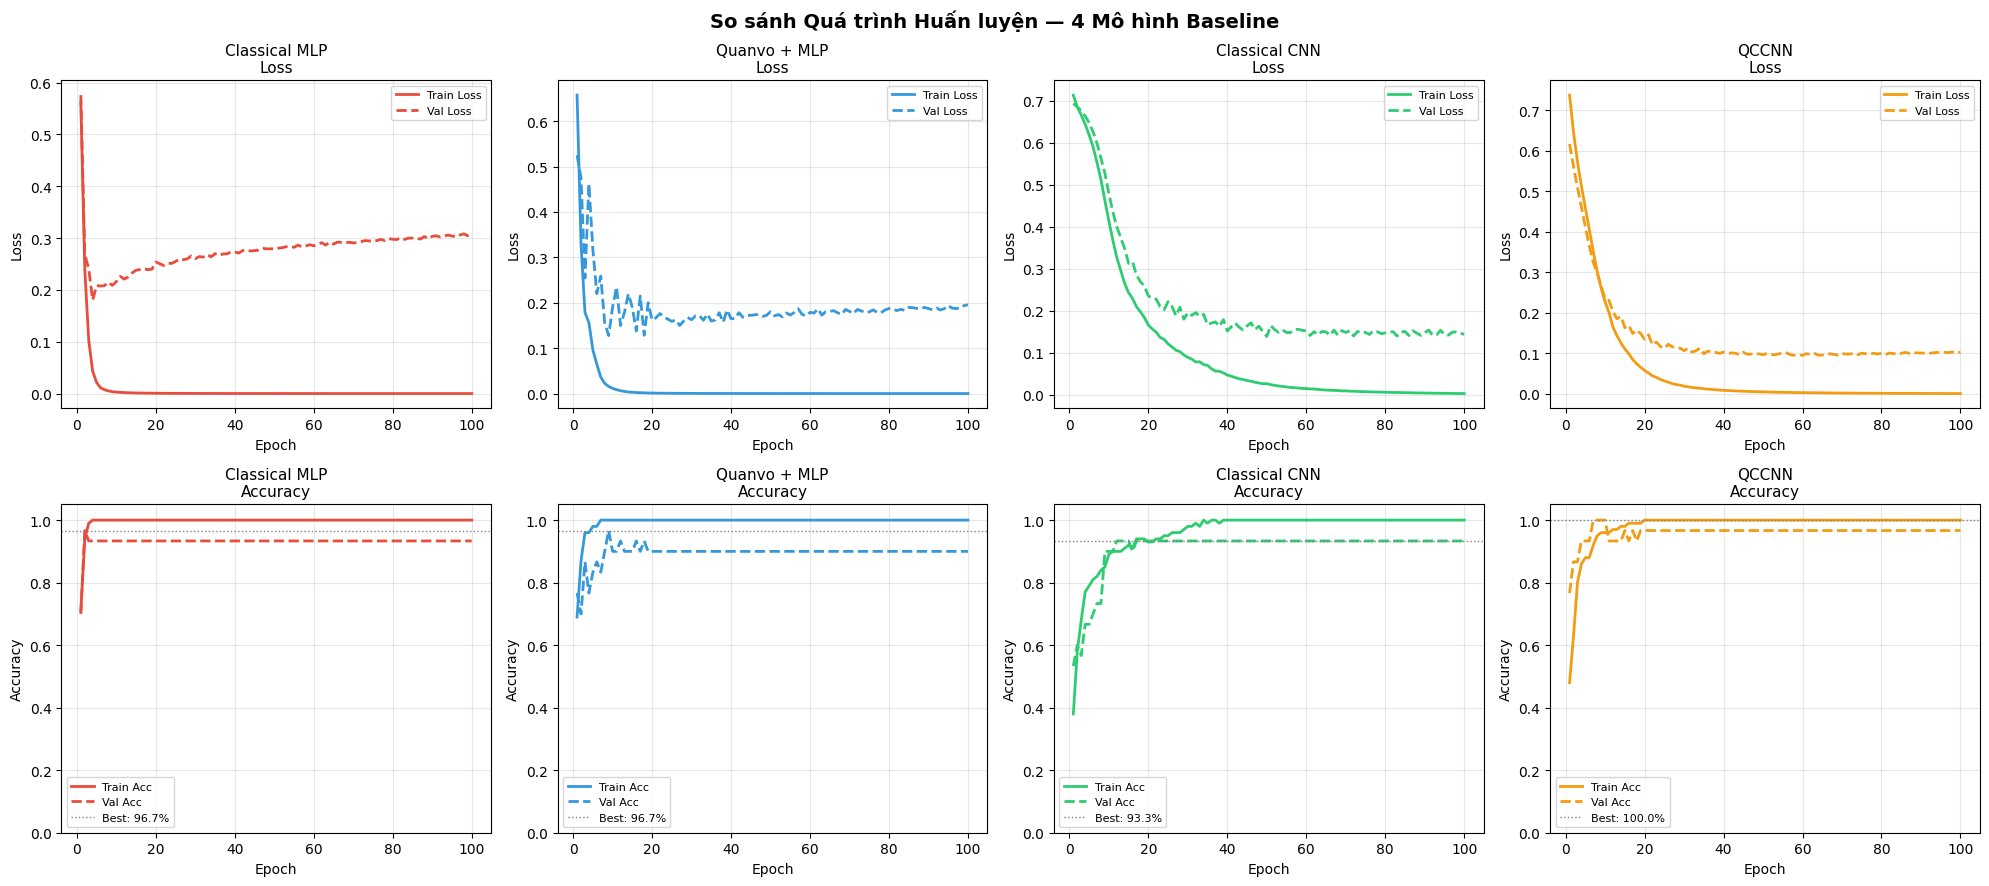

💾 Đã lưu: baseline_training_curves.png


In [ ]:
# ============================================================
# BƯỚC 6A: VẼ ĐƯỜNG CONG LOSS/ACCURACY CỦA BASELINE
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('So sánh Quá trình Huấn luyện — 4 Mô hình Baseline', fontsize=14, fontweight='bold')

baseline_data = [
    (history_classical_mlp, "Classical MLP",     0),
    (history_quanvo_mlp,    "Quanvo + MLP",      1),
    (history_classical_cnn, "Classical CNN",     2),
    (history_qccnn,         "QCCNN",             3),
]

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for hist, name, col_idx in baseline_data:
    epochs_range = range(1, len(hist.history['loss']) + 1)
    c = colors[col_idx]

    # --- Hàng 1: Loss ---
    ax = axes[0, col_idx]
    ax.plot(epochs_range, hist.history['loss'],     color=c,   lw=2,   label='Train Loss')
    ax.plot(epochs_range, hist.history['val_loss'], color=c, lw=2, ls='--', label='Val Loss')
    ax.set_title(f'{name}\nLoss', fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # --- Hàng 2: Accuracy ---
    ax = axes[1, col_idx]
    ax.plot(epochs_range, hist.history['accuracy'],     color=c,   lw=2,   label='Train Acc')
    ax.plot(epochs_range, hist.history['val_accuracy'], color=c, lw=2, ls='--', label='Val Acc')
    ax.axhline(max(hist.history['val_accuracy']), color='gray', ls=':', lw=1,
               label=f"Best: {max(hist.history['val_accuracy'])*100:.1f}%")
    ax.set_title(f'{name}\nAccuracy', fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_ylim([0, 1.05])
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Đã lưu: baseline_training_curves.png")

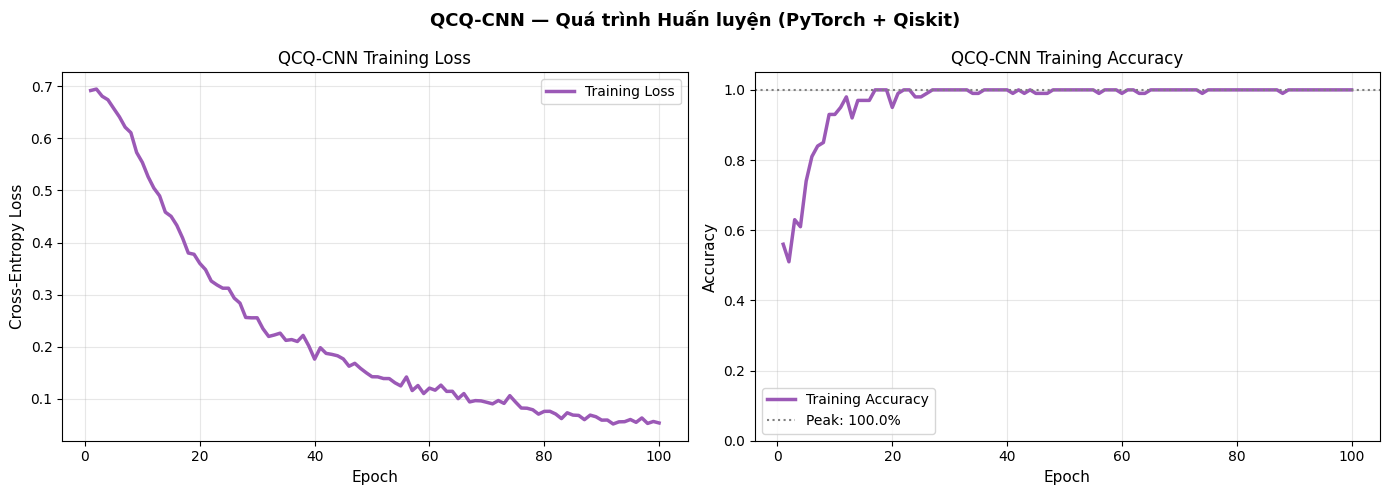

💾 Đã lưu: qcq_cnn_training_curves.png
📊 Loss cuối cùng: 0.0540 | Accuracy cuối: 100.0%


In [ ]:
# ============================================================
# BƯỚC 6B: VẼ ĐƯỜNG CONG LOSS/ACCURACY CỦA QCQ-CNN
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('QCQ-CNN — Quá trình Huấn luyện (PyTorch + Qiskit)', fontsize=13, fontweight='bold')

epochs_range = range(1, len(loss_qcq) + 1)

# Loss
axes[0].plot(epochs_range, loss_qcq, color='#9b59b6', lw=2.5, label='Training Loss')
axes[0].set_title('QCQ-CNN Training Loss', fontsize=12)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Cross-Entropy Loss', fontsize=11)
axes[0].grid(alpha=0.3)
axes[0].legend()

# Accuracy
axes[1].plot(epochs_range, [a/100 for a in acc_qcq], color='#9b59b6', lw=2.5, label='Training Accuracy')
axes[1].axhline(max(acc_qcq)/100, color='gray', ls=':', lw=1.5,
                label=f"Peak: {max(acc_qcq):.1f}%")
axes[1].set_title('QCQ-CNN Training Accuracy', fontsize=12)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Accuracy', fontsize=11)
axes[1].set_ylim([0, 1.05])
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig('qcq_cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Đã lưu: qcq_cnn_training_curves.png")
print(f"📊 Loss cuối cùng: {loss_qcq[-1]:.4f} | Accuracy cuối: {acc_qcq[-1]:.1f}%")


📊 Kết quả đánh giá QCQ-CNN trên test set:
   Ma trận nhầm lẫn (số mẫu):
[[13  2]
 [ 0 15]]
   Accuracy tổng thể: 93.3%


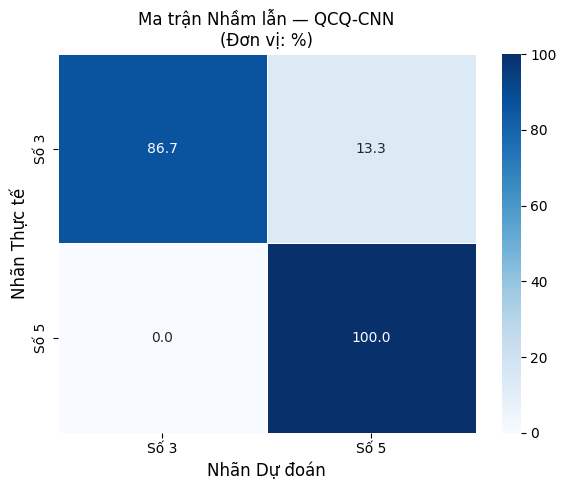


📊 BẢNG SO SÁNH KẾT QUẢ TỔNG HỢP
Mô hình                | Val Accuracy
--------------------------------------
Classical MLP          |       96.7%
Quanvo + MLP           |       96.7%
Classical CNN          |       93.3%
QCCNN (Keras)          |      100.0%
QCQ-CNN (Ours)         |      100.0% ⭐


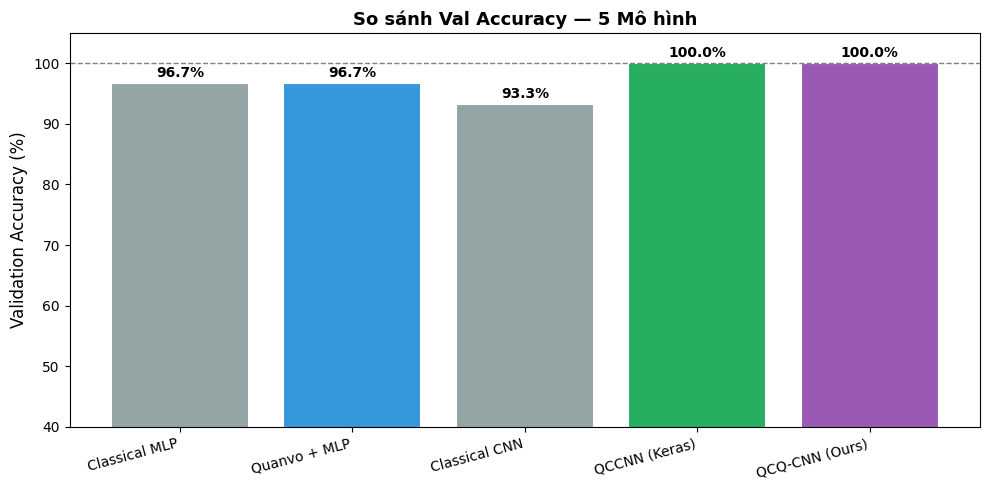

💾 Đã lưu: model_comparison.png


In [ ]:
# ============================================================
# BƯỚC 6C: MA TRẬN NHẦM LẪN CHO QCQ-CNN
# ============================================================

def plot_confusion_matrix(model, test_loader, class_names=["Số 3", "Số 5"],
                          model_name="QCQ-CNN", device='cpu'):
    """
    Tính và vẽ ma trận nhầm lẫn (dạng phần trăm) cho mô hình PyTorch.
    """
    model.eval()  # Tắt Dropout khi đánh giá
    all_preds  = []
    all_labels = []

    with torch.no_grad():  # Không tính gradient → tiết kiệm bộ nhớ
        for data, target in test_loader:
            output = model(data.to(device))
            preds  = output.argmax(dim=1).cpu()
            all_preds.extend(preds.numpy())
            all_labels.extend(target.numpy())

    # Tính ma trận nhầm lẫn tuyệt đối
    cm = confusion_matrix(all_labels, all_preds)

    # Chuẩn hóa về phần trăm theo từng hàng (theo lớp thực tế)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    # In kết quả số
    overall_acc = std_np.trace(cm) / std_np.sum(cm) * 100
    print(f"\n📊 Kết quả đánh giá {model_name} trên test set:")
    print(f"   Ma trận nhầm lẫn (số mẫu):\n{cm}")
    print(f"   Accuracy tổng thể: {overall_acc:.1f}%")

    # Vẽ heatmap
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm_pct, annot=True, fmt=".1f", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names,
        ax=ax, linewidths=0.5, linecolor='white',
        vmin=0, vmax=100
    )
    ax.set_ylabel("Nhãn Thực tế", fontsize=12)
    ax.set_xlabel("Nhãn Dự đoán", fontsize=12)
    ax.set_title(f"Ma trận Nhầm lẫn — {model_name}\n(Đơn vị: %)", fontsize=12)
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{model_name.replace(" ", "_")}.png', dpi=150)
    plt.show()


# Vẽ confusion matrix cho QCQ-CNN
plot_confusion_matrix(model_qcq_cnn, test_loader,
                      class_names=["Số 3", "Số 5"],
                      model_name="QCQ-CNN",
                      device=str(device))

# ============================================================
# BƯỚC 6D: BẢNG SO SÁNH TỔNG HỢP
# ============================================================

print("\n" + "=" * 60)
print("📊 BẢNG SO SÁNH KẾT QUẢ TỔNG HỢP")
print("=" * 60)

results = {
    "Classical MLP":  max(history_classical_mlp.history['val_accuracy']) * 100,
    "Quanvo + MLP":   max(history_quanvo_mlp.history['val_accuracy'])    * 100,
    "Classical CNN":  max(history_classical_cnn.history['val_accuracy']) * 100,
    "QCCNN (Keras)":  max(history_qccnn.history['val_accuracy'])         * 100,
    "QCQ-CNN (Ours)": max(acc_qcq),
}

print(f"{'Mô hình':<22} | {'Val Accuracy':>12}")
print("-" * 38)
for name, acc in results.items():
    marker = " ⭐" if name == "QCQ-CNN (Ours)" else ""
    print(f"{name:<22} | {acc:>10.1f}%{marker}")

# Biểu đồ thanh so sánh
fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = ['#95a5a6', '#3498db', '#95a5a6', '#27ae60', '#9b59b6']
bars = ax.bar(list(results.keys()), list(results.values()), color=colors_bar, edgecolor='white', linewidth=1.5)
ax.set_ylabel('Validation Accuracy (%)', fontsize=12)
ax.set_title('So sánh Val Accuracy — 5 Mô hình', fontsize=13, fontweight='bold')
ax.set_ylim([40, 105])
ax.axhline(y=max(results.values()), color='gray', ls='--', lw=1)
for bar, val in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Đã lưu: model_comparison.png")

---
## 💾 BƯỚC 7: Lưu Trọng số Mô hình

### Giải thích:

Sau khi huấn luyện, ta cần **lưu trọng số mô hình** để có thể tải lại sau mà không cần huấn luyện lại (đặc biệt quan trọng với QNN — tốn nhiều thời gian).

#### Cách lưu trong PyTorch:
- **`torch.save(model.state_dict(), path)`**: Chỉ lưu trọng số (khuyến nghị). Cần định nghĩa lại kiến trúc trước khi load.
- **`torch.save(model, path)`**: Lưu cả kiến trúc + trọng số (tiện hơn nhưng phụ thuộc cấu trúc code).

Ta dùng `state_dict()` theo thực hành tốt nhất của PyTorch.

#### Cách lưu trong Keras:
- **`model.save(path)`**: Lưu toàn bộ model (kiến trúc + trọng số + trạng thái optimizer).

In [ ]:
# ============================================================
# BƯỚC 7: LƯU TRỌNG SỐ MÔ HÌNH
# ============================================================

import os
SAVE_DIR = "saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)  # Tạo thư mục nếu chưa có

# --- Lưu mô hình QCQ-CNN (PyTorch) ---
# Cách 1: Lưu state_dict (khuyến nghị)
qcq_path = os.path.join(SAVE_DIR, "qcq_cnn_weights.pt")
torch.save(model_qcq_cnn.state_dict(), qcq_path)
print(f"✅ Đã lưu QCQ-CNN weights: {qcq_path}")

# Cách 2: Lưu toàn bộ mô hình
qcq_full_path = os.path.join(SAVE_DIR, "qcq_cnn_full.pt")
torch.save(model_qcq_cnn, qcq_full_path)
print(f"✅ Đã lưu QCQ-CNN full model: {qcq_full_path}")

# --- Lưu lịch sử huấn luyện QCQ-CNN ---
training_history = {
    'loss_qcq': loss_qcq,
    'acc_qcq':  acc_qcq,
    'epochs':   N_EPOCHS,
}
import json
hist_path = os.path.join(SAVE_DIR, "training_history.json")
with open(hist_path, 'w') as f:
    json.dump(training_history, f, indent=2)
print(f"✅ Đã lưu lịch sử huấn luyện: {hist_path}")

# --- Lưu các baseline Keras ---
for keras_model, name in [
    (model_classical_mlp, "classical_mlp"),
    (model_quanvo_mlp,    "quanvo_mlp"),
    (model_classical_cnn, "classical_cnn"),
    (model_qccnn,         "qccnn"),
]:
    k_path = os.path.join(SAVE_DIR, f"{name}.keras")
    keras_model.save(k_path)
    print(f"✅ Đã lưu Keras model: {k_path}")

# --- Hướng dẫn tải lại ---
print("\n" + "=" * 55)
print("📖 HƯỚNG DẪN TẢI LẠI MÔ HÌNH:")
print("=" * 55)
print("""
# Tải lại QCQ-CNN (PyTorch):
qnn_new   = create_qnn()
model_new = QCQ_CNN(qnn_new).to(device)

# Cần chạy một lần để khởi tạo fc2:
dummy = torch.zeros(1, 4, 14, 14).to(device)
_ = model_new(dummy)

# Tải trọng số:
model_new.load_state_dict(torch.load('saved_models/qcq_cnn_weights.pt'))
model_new.eval()

# Tải Keras model:
loaded_keras = keras.models.load_model('saved_models/qccnn.keras')
""")

✅ Đã lưu QCQ-CNN weights: saved_models/qcq_cnn_weights.pt
✅ Đã lưu QCQ-CNN full model: saved_models/qcq_cnn_full.pt
✅ Đã lưu lịch sử huấn luyện: saved_models/training_history.json
✅ Đã lưu Keras model: saved_models/classical_mlp.keras
✅ Đã lưu Keras model: saved_models/quanvo_mlp.keras
✅ Đã lưu Keras model: saved_models/classical_cnn.keras
✅ Đã lưu Keras model: saved_models/qccnn.keras

📖 HƯỚNG DẪN TẢI LẠI MÔ HÌNH:

# Tải lại QCQ-CNN (PyTorch):
qnn_new   = create_qnn()
model_new = QCQ_CNN(qnn_new).to(device)

# Cần chạy một lần để khởi tạo fc2:
dummy = torch.zeros(1, 4, 14, 14).to(device)
_ = model_new(dummy)

# Tải trọng số:
model_new.load_state_dict(torch.load('saved_models/qcq_cnn_weights.pt'))
model_new.eval()

# Tải Keras model:
loaded_keras = keras.models.load_model('saved_models/qccnn.keras')



---
## 🔍 BƯỚC 8: Kiểm tra trên Ảnh Ngẫu nhiên Chưa thấy

### Giải thích:

Bước cuối cùng là **kiểm tra tính tổng quát** của mô hình QCQ-CNN bằng cách dự đoán trên các ảnh **ngẫu nhiên từ test set** — tức là những ảnh mô hình **chưa hề gặp trong quá trình huấn luyện**.

Quy trình:
1. Lấy ngẫu nhiên $k$ ảnh từ tập test
2. Qua Quanvolutional Layer → đặc trưng lượng tử
3. Qua QCQ-CNN PyTorch → dự đoán
4. So sánh với nhãn thực

Đây là **"bài kiểm tra cuối cùng"** — nếu mô hình dự đoán đúng trên ảnh chưa thấy, nó đã thực sự học được đặc trưng tổng quát chứ không chỉ ghi nhớ (memorize) dữ liệu huấn luyện.

⚛️  Đang trích xuất đặc trưng lượng tử cho 10 ảnh mới...
✅ Quanvolutional_Layer khởi tạo thành công!
   Backend   : lightning.qubit (C++ — nhanh)
   Bộ lọc   : 2×2, Stride: 2
   Số qubit  : 4, Số kênh đầu ra: 1
   Kích thước input mỗi ảnh : 28×28
   Kích thước output mỗi ảnh: 14×14×4


⚛️  Quanvolution:   0%|          | 0/10 [00:00<?, ?it/s]

✅ Xử lý xong 10 ảnh!


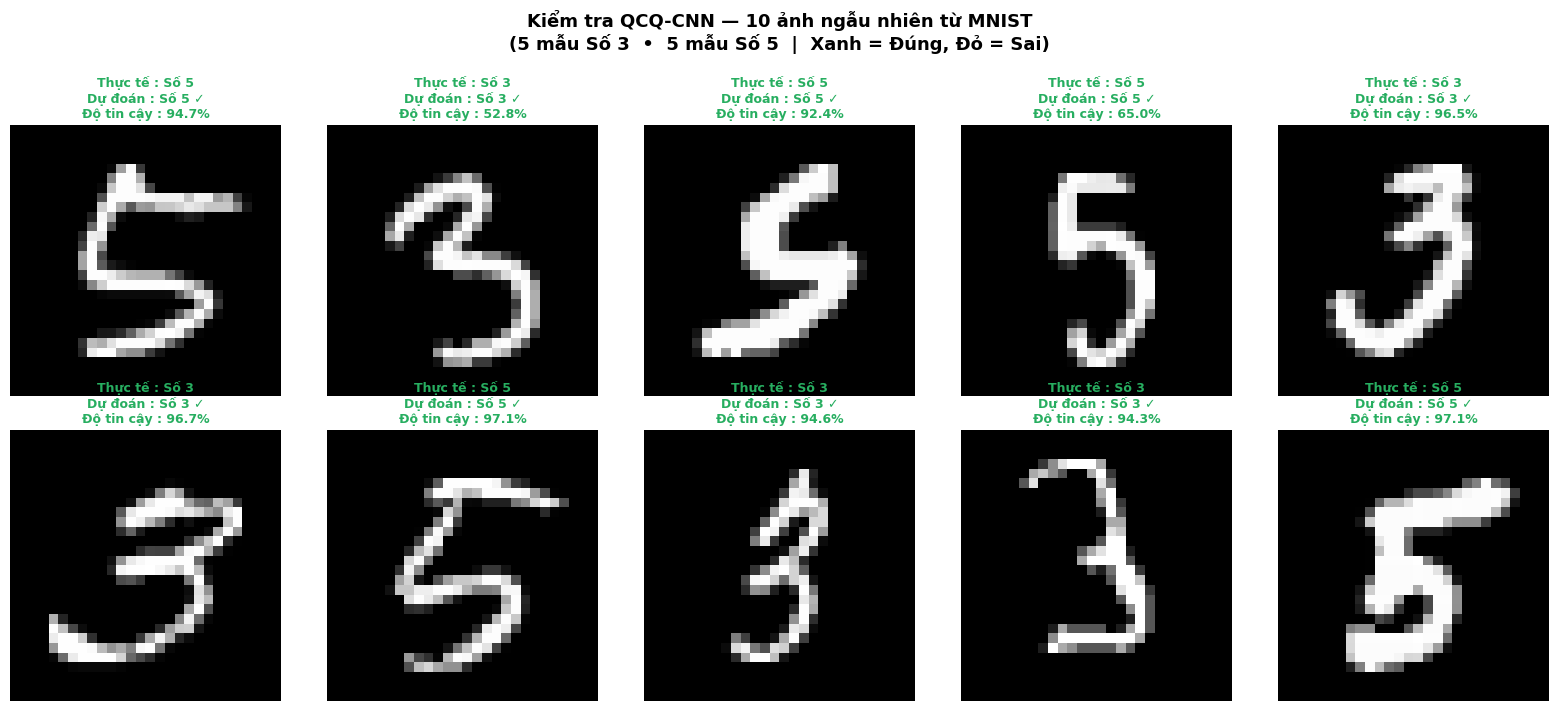


📊 KẾT QUẢ CHI TIẾT — 10 ảnh (5 mỗi lớp)
  # |  Thực tế |  Dự đoán |  P(Số 3) |  P(Số 5) |  Kết quả
──────────────────────────────────────────────────────────────
  1 |     Số 5 |     Số 5 |    5.3%  |   94.7%  | ✓ Đúng
  2 |     Số 3 |     Số 3 |   52.8%  |   47.2%  | ✓ Đúng
  3 |     Số 5 |     Số 5 |    7.6%  |   92.4%  | ✓ Đúng
  4 |     Số 5 |     Số 5 |   35.0%  |   65.0%  | ✓ Đúng
  5 |     Số 3 |     Số 3 |   96.5%  |    3.5%  | ✓ Đúng
  6 |     Số 3 |     Số 3 |   96.7%  |    3.3%  | ✓ Đúng
  7 |     Số 5 |     Số 5 |    2.9%  |   97.1%  | ✓ Đúng
  8 |     Số 3 |     Số 3 |   94.6%  |    5.4%  | ✓ Đúng
  9 |     Số 3 |     Số 3 |   94.3%  |    5.7%  | ✓ Đúng
 10 |     Số 5 |     Số 5 |    2.9%  |   97.1%  | ✓ Đúng
──────────────────────────────────────────────────────────────
Số 3 : 5/5 đúng  |  Số 5 : 5/5 đúng  |  Tổng : 10/10 = 100.0%

💾 Đã lưu: random_predictions.png


In [ ]:
# ============================================================
# BƯỚC 8: KIỂM TRA TRÊN ẢNH NGẪU NHIÊN CHƯA THẤY
# Lấy từ toàn bộ tập MNIST (không giới hạn trong test set nhỏ)
# Đảm bảo đúng 5 mẫu mỗi lớp (số 3 và số 5)
# ============================================================

def predict_random_samples_balanced(model, class_names=["Số 3", "Số 5"],
                                    n_per_class=5, device='cpu', seed=None):
    """
    Lấy ngẫu nhiên n_per_class ảnh mỗi lớp từ toàn bộ tập MNIST gốc
    (loại trừ các ảnh đã dùng trong train/test set của dự án).

    Tham số:
        model        : Mô hình QCQ-CNN đã huấn luyện
        class_names  : Tên hiển thị cho mỗi lớp
        n_per_class  : Số mẫu mỗi lớp (mặc định 5 → tổng 10)
        device       : Thiết bị PyTorch để chạy inference
        seed         : Seed ngẫu nhiên để tái lập kết quả
    """
    if seed is not None:
        std_np.random.seed(seed)

    n_total = n_per_class * 2  # Tổng số ảnh cần hiển thị

    # ----------------------------------------------------------
    # 1. Tải lại toàn bộ MNIST để lấy pool ảnh lớn hơn
    #    (không bị giới hạn bởi 30 ảnh test set nhỏ của dự án)
    # ----------------------------------------------------------
    (all_tr_imgs, all_tr_lbls), (all_te_imgs, all_te_lbls) = \
        keras.datasets.mnist.load_data()

    # Ghép train + test thành một pool lớn duy nhất
    all_imgs = std_np.concatenate([all_tr_imgs, all_te_imgs], axis=0)  # (70000, 28, 28)
    all_lbls = std_np.concatenate([all_tr_lbls, all_te_lbls], axis=0)  # (70000,)

    # Chuẩn hóa pixel về [0,1] — bắt buộc cho Angle Encoding
    all_imgs = all_imgs.astype(std_np.float32) / 255.0

    # ----------------------------------------------------------
    # 2. Lọc chỉ lấy số 3 và số 5, ánh xạ nhãn {3,5} → {0,1}
    # ----------------------------------------------------------
    mask = std_np.isin(all_lbls, TARGET_LABELS)
    pool_imgs = all_imgs[mask]                                           # (N_pool, 28, 28)
    pool_lbls = (all_lbls[mask] == TARGET_LABELS[1]).astype(std_np.int32)  # 0=số3, 1=số5

    # ----------------------------------------------------------
    # 3. Chọn ngẫu nhiên đúng n_per_class mẫu mỗi lớp
    # ----------------------------------------------------------
    selected_imgs  = []
    selected_lbls  = []

    for class_idx in [0, 1]:
        # Lấy tất cả chỉ số thuộc lớp class_idx
        candidate_indices = std_np.where(pool_lbls == class_idx)[0]
        # Chọn ngẫu nhiên n_per_class trong số đó
        chosen = std_np.random.choice(candidate_indices, size=n_per_class, replace=False)
        selected_imgs.append(pool_imgs[chosen])
        selected_lbls.append(pool_lbls[chosen])

    # Xáo trộn để 2 lớp không đứng riêng thành 2 hàng
    selected_imgs = std_np.concatenate(selected_imgs, axis=0)   # (10, 28, 28)
    selected_lbls = std_np.concatenate(selected_lbls, axis=0)   # (10,)
    shuffle_order = std_np.random.permutation(n_total)
    selected_imgs = selected_imgs[shuffle_order]
    selected_lbls = selected_lbls[shuffle_order]

    # ----------------------------------------------------------
    # 4. Trích xuất đặc trưng lượng tử cho 10 ảnh mới này
    #    (thêm chiều channel để Quanvolutional_Layer xử lý đúng)
    # ----------------------------------------------------------
    print(f"⚛️  Đang trích xuất đặc trưng lượng tử cho {n_total} ảnh mới...")
    imgs_with_channel = selected_imgs[:, :, :, std_np.newaxis]  # (10, 28, 28, 1)

    Quan2D_infer = Quanvolutional_Layer(
        size_filter=2, layers_filter=1, stride_filter=2, padding=0
    )
    features_list = Quan2D_infer.call(imgs_with_channel)
    features_np   = std_np.asarray(features_list, dtype=std_np.float32)  # (10, 14, 14, 4)

    # ----------------------------------------------------------
    # 5. Chạy inference qua QCQ-CNN
    # ----------------------------------------------------------
    model.eval()
    results_detail = []

    for i in range(n_total):
        # (14, 14, 4) → (1, 4, 14, 14): channels-first cho PyTorch
        feat_tensor = torch.tensor(
            features_np[i].transpose(2, 0, 1)[std_np.newaxis, :],
            dtype=torch.float32
        ).to(device)

        with torch.no_grad():
            output = model(feat_tensor)
            probs  = torch.softmax(output, dim=1).cpu().numpy()[0]
            pred   = output.argmax(dim=1).item()

        label      = selected_lbls[i]
        is_correct = (pred == label)
        results_detail.append({
            'image'    : selected_imgs[i],   # (28, 28) để hiển thị
            'true'     : int(label),
            'pred'     : int(pred),
            'prob_cls0': float(probs[0]),
            'prob_cls1': float(probs[1]),
            'correct'  : is_correct,
        })

    # ----------------------------------------------------------
    # 6. Vẽ lưới 2 hàng × 5 cột
    #    Hàng trên: 5 mẫu đầu | Hàng dưới: 5 mẫu sau
    # ----------------------------------------------------------
    fig, axes = plt.subplots(2, n_per_class, figsize=(16, 7))
    fig.suptitle(
        'Kiểm tra QCQ-CNN — 10 ảnh ngẫu nhiên từ MNIST\n'
        '(5 mẫu Số 3  •  5 mẫu Số 5  |  Xanh = Đúng, Đỏ = Sai)',
        fontsize=13, fontweight='bold', y=1.01
    )

    for plot_idx, r in enumerate(results_detail):
        row = plot_idx // n_per_class
        col = plot_idx %  n_per_class
        ax  = axes[row, col]

        ax.imshow(r['image'], cmap='gray', interpolation='nearest')

        color  = '#27ae60' if r['correct'] else '#e74c3c'   # Xanh / Đỏ
        status = '✓' if r['correct'] else '✗'
        prob_shown = r['prob_cls1'] if r['pred'] == 1 else r['prob_cls0']

        ax.set_title(
            f"Thực tế : {class_names[r['true']]}\n"
            f"Dự đoán : {class_names[r['pred']]} {status}\n"
            f"Độ tin cậy : {prob_shown*100:.1f}%",
            color=color, fontsize=9, fontweight='bold', pad=6
        )
        ax.axis('off')

        # Viền màu quanh ảnh
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor(color)
            spine.set_linewidth(3)

    plt.tight_layout()
    plt.savefig('random_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ----------------------------------------------------------
    # 7. Bảng kết quả chi tiết
    # ----------------------------------------------------------
    n_correct = sum(r['correct'] for r in results_detail)
    print(f"\n{'='*62}")
    print(f"📊 KẾT QUẢ CHI TIẾT — {n_total} ảnh ({n_per_class} mỗi lớp)")
    print(f"{'='*62}")
    print(f"{'#':>3} | {'Thực tế':>8} | {'Dự đoán':>8} | "
          f"{'P(Số 3)':>8} | {'P(Số 5)':>8} | {'Kết quả':>8}")
    print(f"{'─'*62}")

    for i, r in enumerate(results_detail):
        kq = "✓ Đúng" if r['correct'] else "✗ Sai"
        print(f"{i+1:>3} | {class_names[r['true']]:>8} | "
              f"{class_names[r['pred']]:>8} | "
              f"{r['prob_cls0']*100:>6.1f}%  | "
              f"{r['prob_cls1']*100:>6.1f}%  | {kq}")

    print(f"{'─'*62}")
    n_c3 = sum(r['correct'] for r in results_detail if r['true'] == 0)
    n_c5 = sum(r['correct'] for r in results_detail if r['true'] == 1)
    print(f"Số 3 : {n_c3}/{n_per_class} đúng  |  "
          f"Số 5 : {n_c5}/{n_per_class} đúng  |  "
          f"Tổng : {n_correct}/{n_total} = {n_correct/n_total*100:.1f}%")
    print(f"{'='*62}")


# --- Chạy kiểm tra ---
predict_random_samples_balanced(
    model       = model_qcq_cnn,
    class_names = ["Số 3", "Số 5"],
    n_per_class = 5,          # 5 mẫu mỗi lớp → 10 ảnh tổng
    device      = str(device),
    seed        = 42
)

print("\n💾 Đã lưu: random_predictions.png")

---
## 🎓 Tổng kết Dự án

### Những gì đã thực hiện:

| Bước | Nội dung | Framework |
|------|----------|-----------|
| 1 | Import thư viện | PennyLane, PyTorch, Qiskit, TF |
| 2 | Tiền xử lý MNIST (3 vs 5) | NumPy, Keras |
| 3 | Quanvolutional Layer + đặc trưng 14×14×4 | PennyLane |
| 4 | Định nghĩa 4 baseline + QCQ-CNN | Keras, PyTorch+Qiskit |
| 5 | Huấn luyện tất cả mô hình | Keras, PyTorch |
| 6 | Đánh giá, Loss/Accuracy curves, Confusion Matrix | Matplotlib, Seaborn |
| 7 | Lưu trọng số | torch.save, model.save |
| 8 | Test trên ảnh mới chưa thấy | PyTorch inference |

### Kiến trúc QCQ-CNN:
```
Input (28×28×1)
    ↓ [PennyLane] Quanvolutional Layer
Feature Map (14×14×4)  ← ⟨Z_j⟩ từ 4 qubit
    ↓ [PyTorch] Conv2d(4→8) + ReLU + MaxPool
    ↓ [PyTorch] Conv2d(8→16) + ReLU + MaxPool
    ↓ [PyTorch] Flatten + Linear(→2)
Vector 2D
    ↓ [Qiskit] ZZFeatureMap(2) + RealAmplitudes(2, reps=1)
    ↓ [Qiskit] EstimatorQNN → ⟨H⟩
    ↓ [PyTorch] Linear(1→2)
Dự đoán (Số 3 hoặc Số 5)
```